# Análise estatística dos participantes da edição 2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('missoes.csv')
df.columns = df.columns.str.strip()
df.head()

,User,Mission1,Mission2,Mission3,Mission4,Mission5,Mission6,Mission7,Mission8,MissionSpecial
0,UmaPessoaHumana,1,0,1,0,1,0,0,0,1
1,mathamen,0,1,0,0,0,0,0,0,1
2,belovacomics,1,0,0,0,0,0,0,1,1
3,carolina__rosa,1,1,0,1,0,0,0,0,1
4,EdzinhoHowlett,1,1,0,0,0,0,0,0,1


In [3]:
mission_pesos = {
    1: 1,
    2: 1,
    3: 1,
    4: 1,
    5: 1,
    6: 1,
    7: 1,
    8: 1,
    9: 12,
}

total_possivel = sum(mission_pesos.values())

mission_cores = {
    1: "#FF4C4C",
    2: "#FFA500",
    3: "#FFD700",
    4: "#32CD32",
    5: "#008080",
    6: "#00BFFF",
    7: "#8A2BE2",
    8: "#1A1A6E",
    9: "#C71585"
}

mission_nomes = {
    1: "Missão 1: Desafio passado",
    2: "Missão 2: LGBTQIA+",
    3: "Missão 3: Indicação",
    4: "Missão 4: Musical",
    5: "Missão 5: Avós",
    6: "Missão 6: Filme do futuro",
    7: "Missão 7: Filme brasileiro pré-2000",
    8: "Missão 8: Idioma inédito",
    9: "Missão Especial: Países vistos"
}

In [4]:
def contar_missions(df, pessoa):

    pessoa_data = df[df["User"] == pessoa].iloc[0]
    
    preenchimento_mission = {}
    
    # Missões 1 a 8 (valores binários)
    for i in range(1, 9):
        col_name = f"Mission{i}"
        preenchimento_mission[i] = pessoa_data[col_name]
    
    # MissionSpecial (contagem de países, máximo 12)
    paises = pessoa_data["MissionSpecial"]
    preenchimento_mission[9] = min(paises, 12)
    
    return preenchimento_mission

In [5]:
def remover_participantes(participantes, *user_ids):
    # se algum participante perdeu e n vai precisar entrar na análise
    return [p for p in participantes if p not in user_ids]

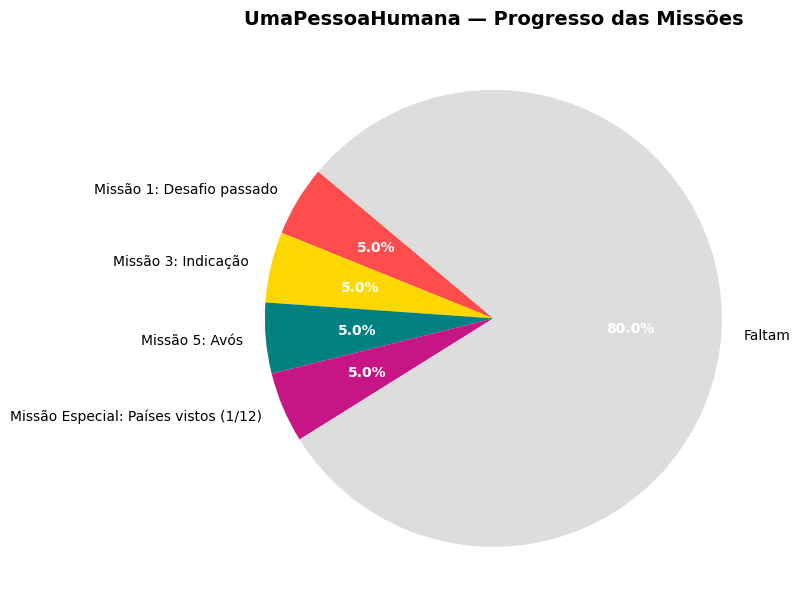

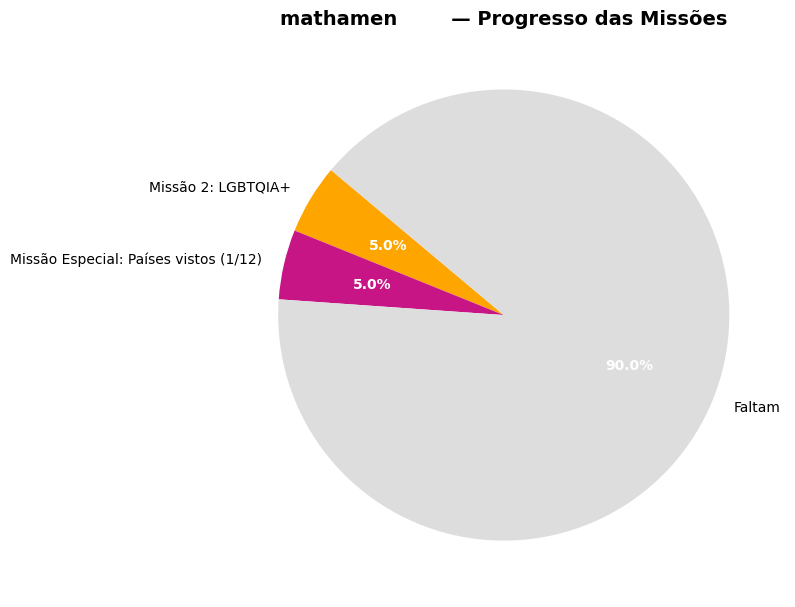

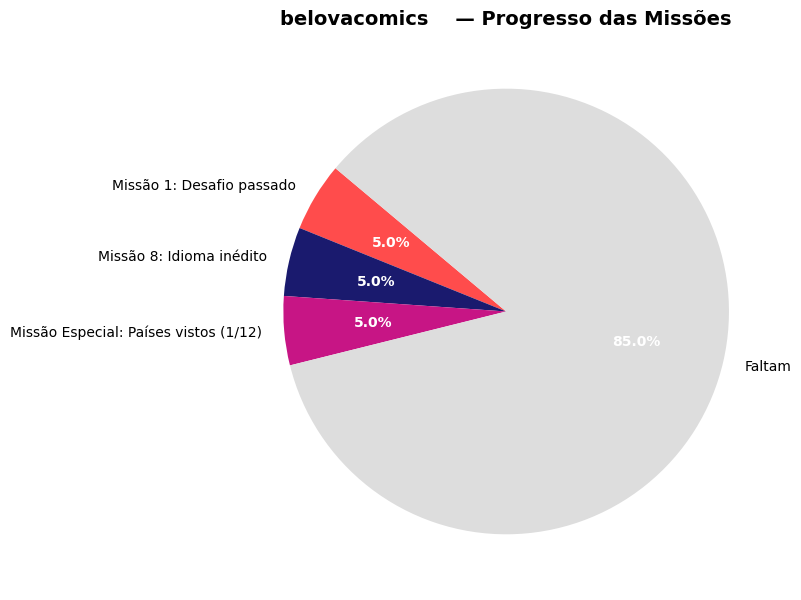

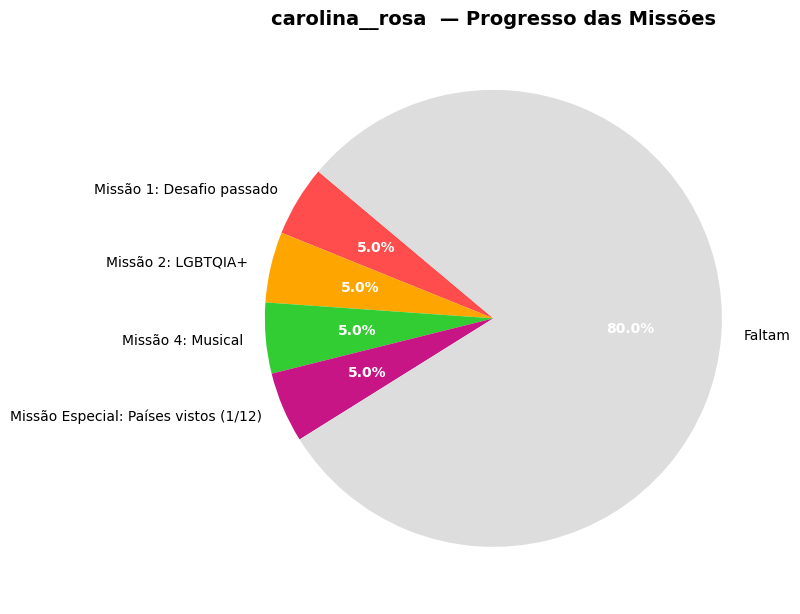

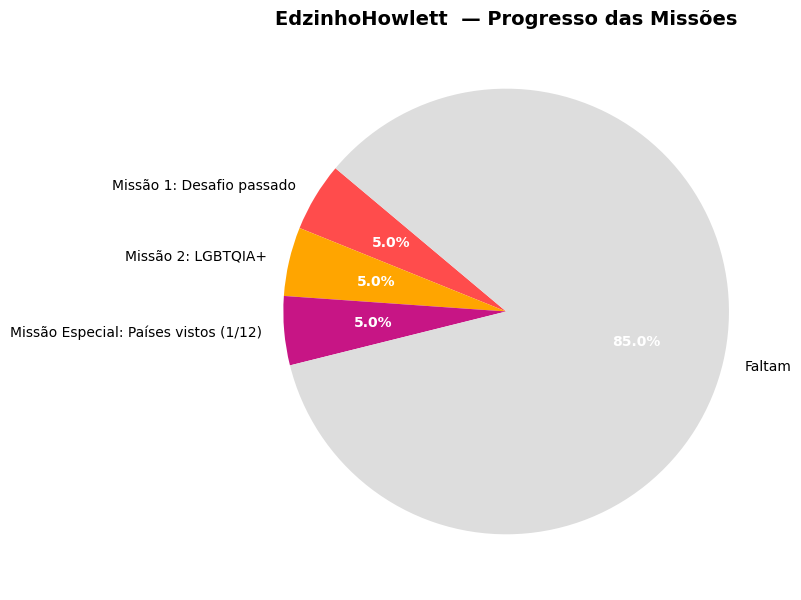

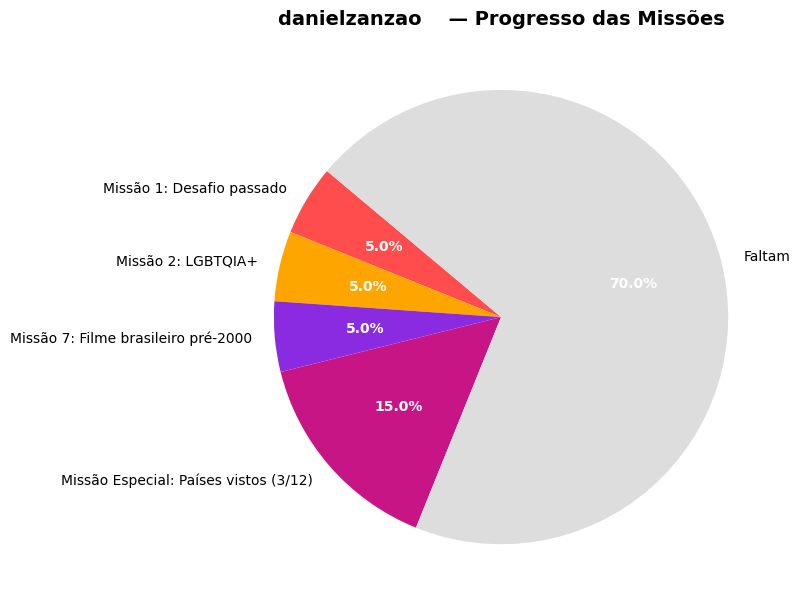

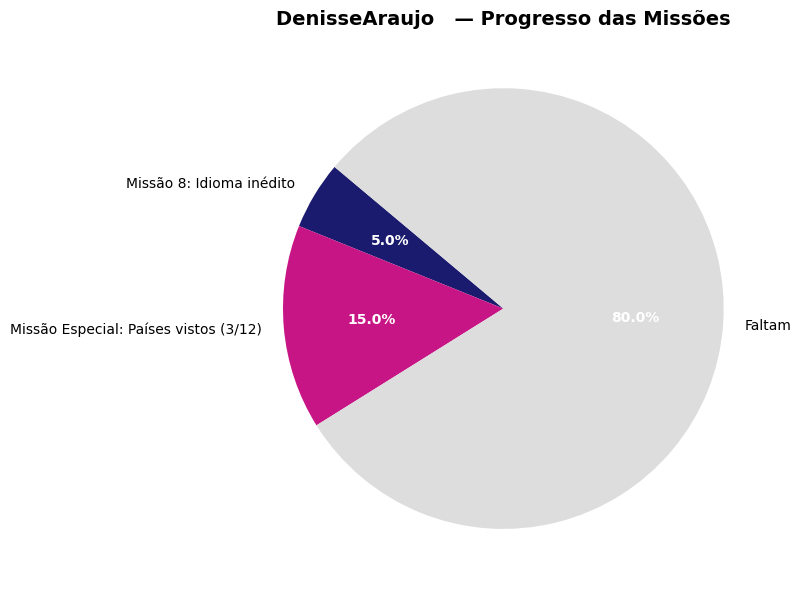

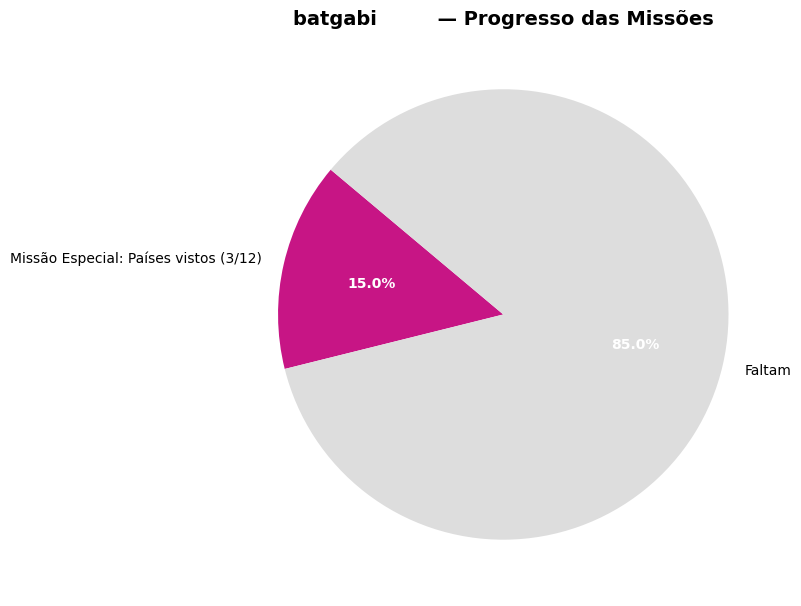

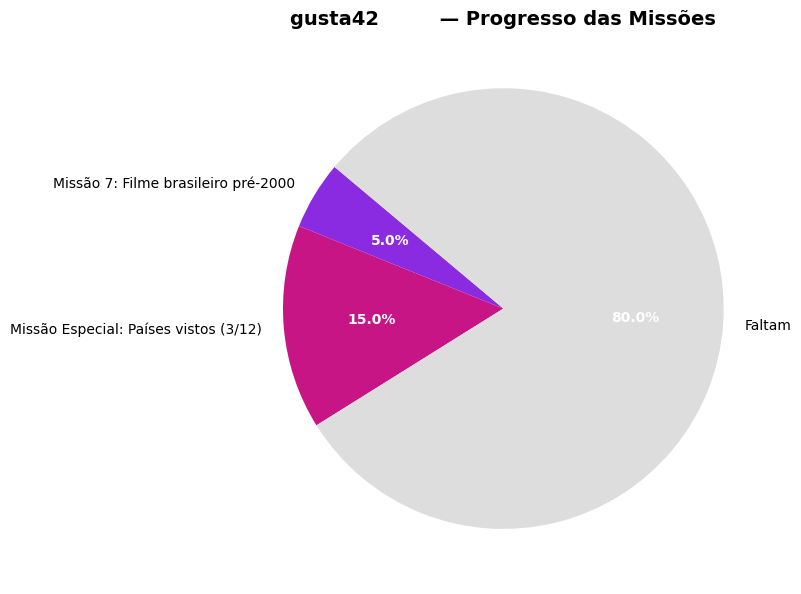

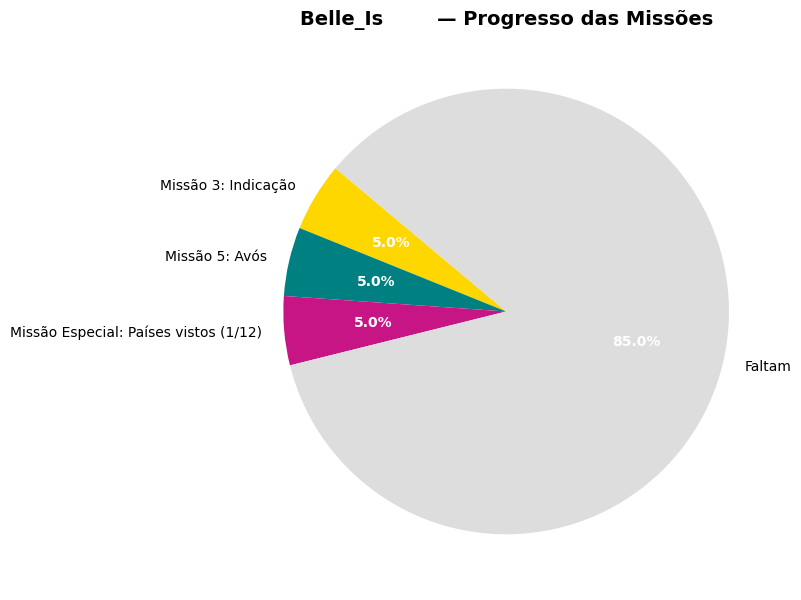

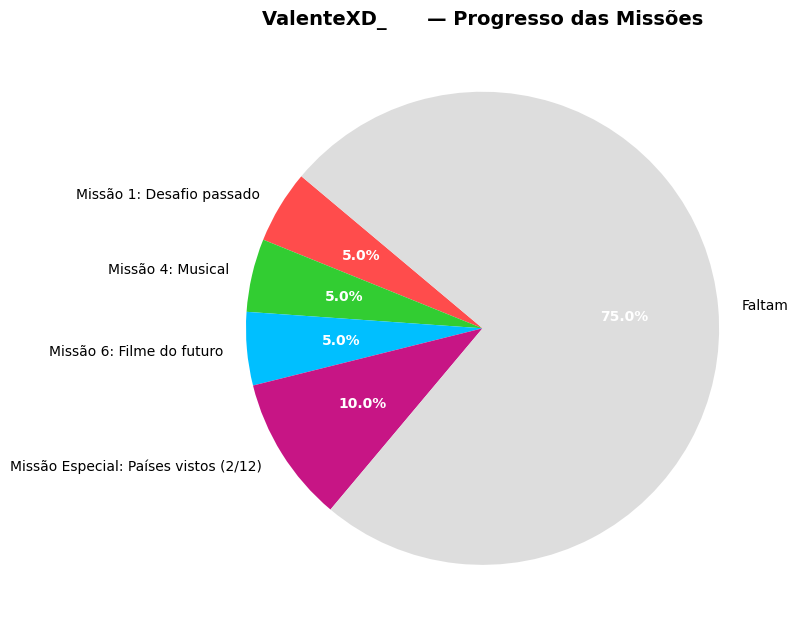

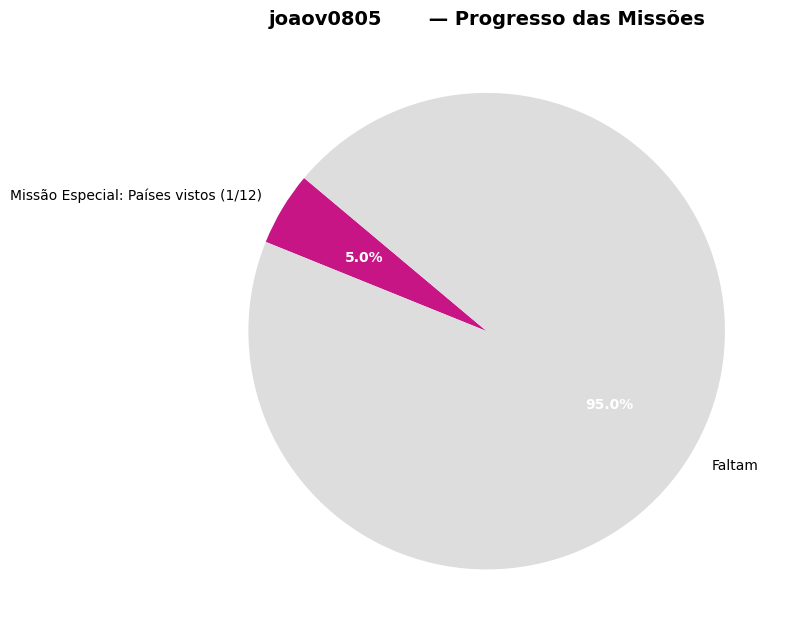

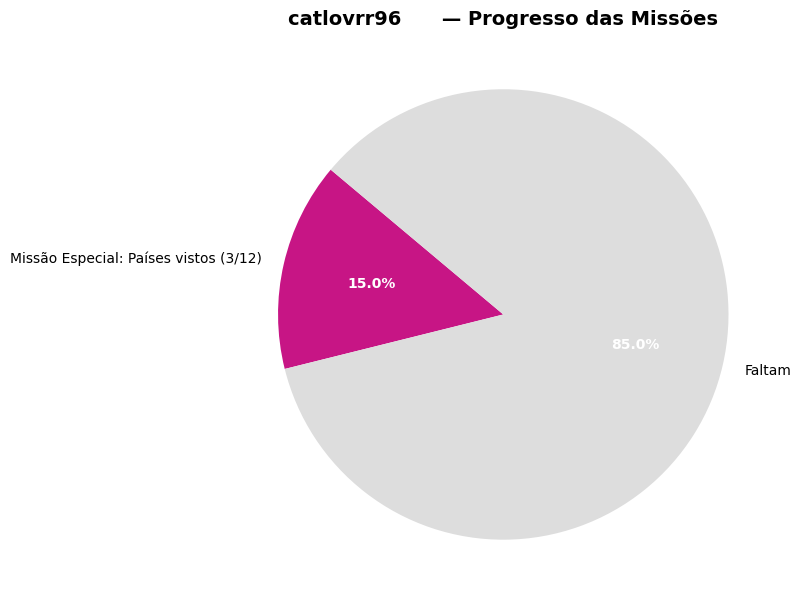

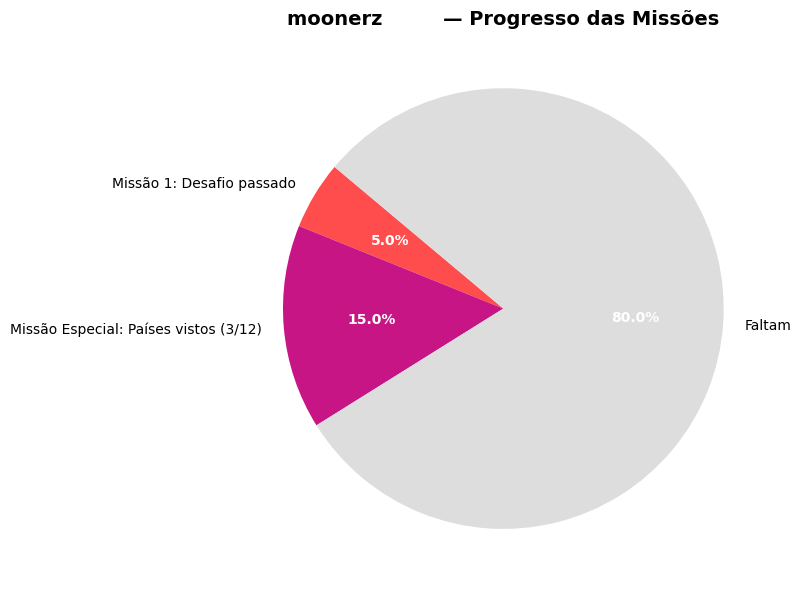

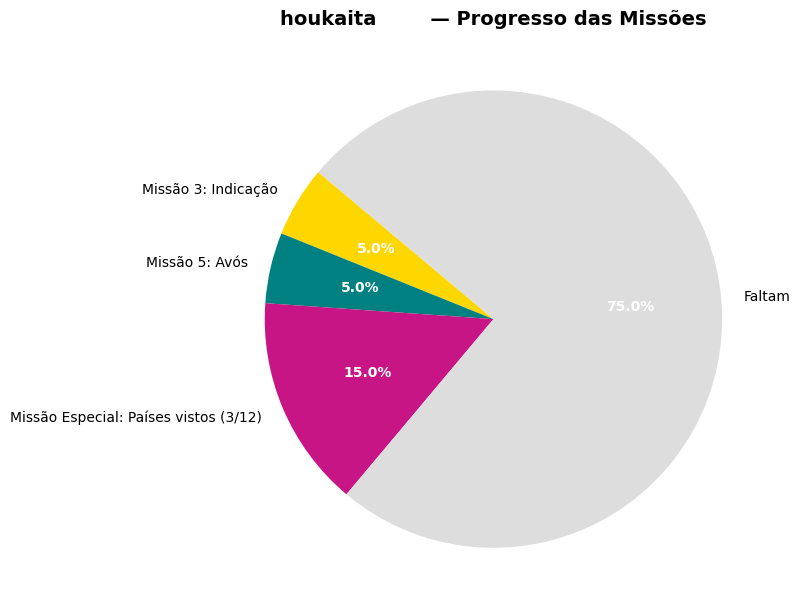

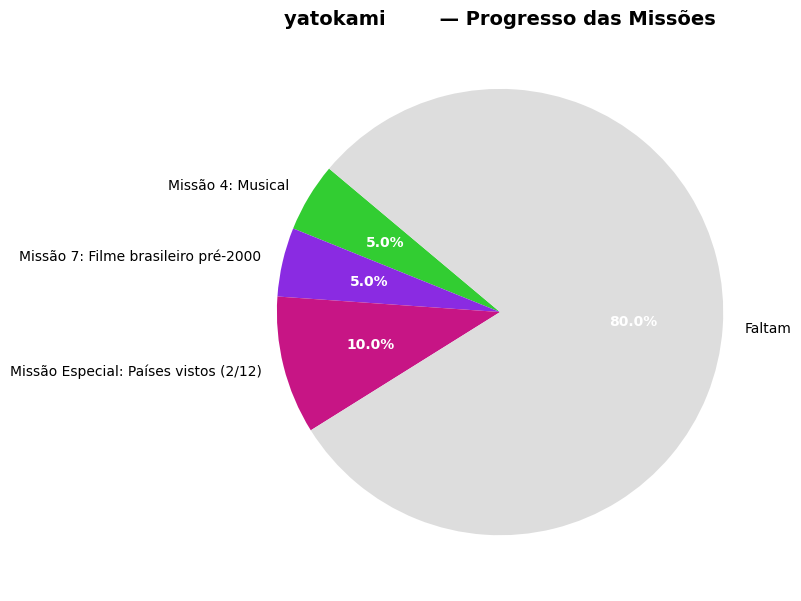

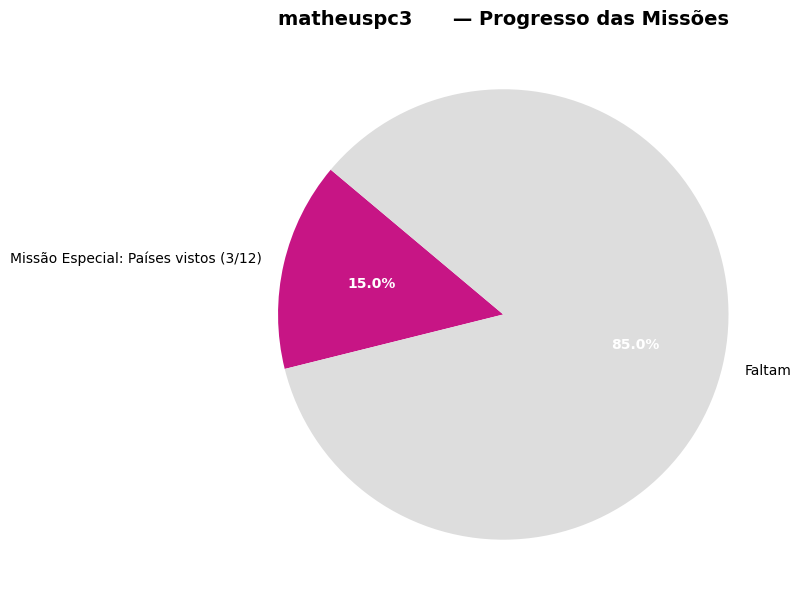

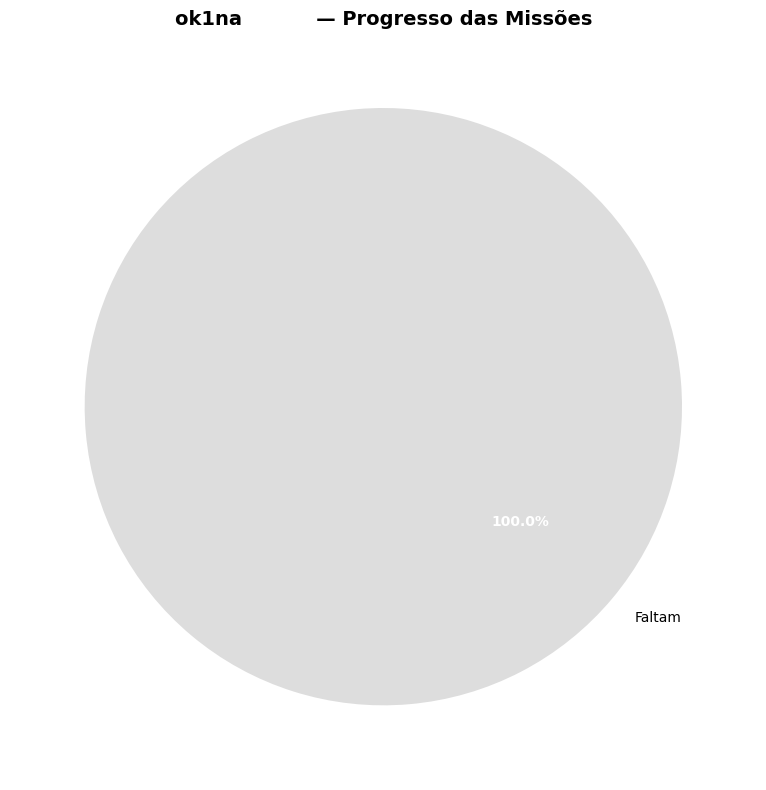

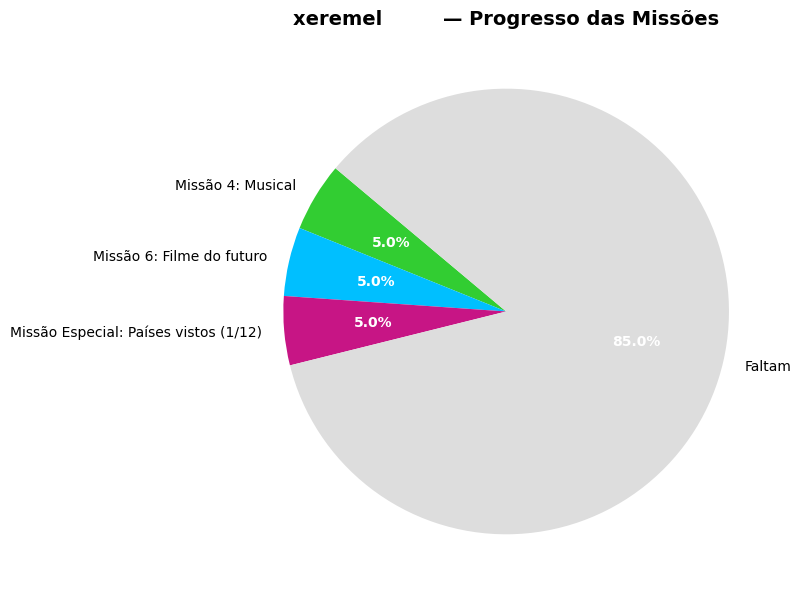

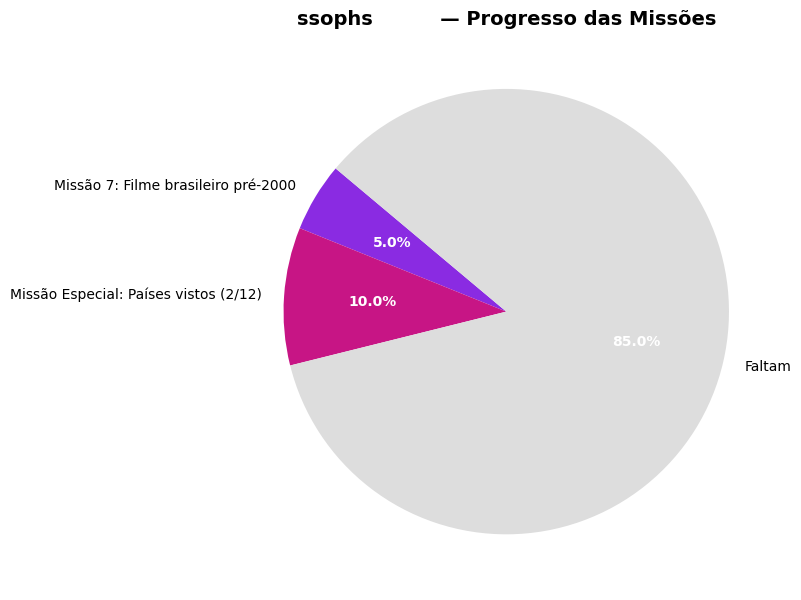

In [6]:
participantes = df["User"].tolist()
participantes = remover_participantes(participantes, "Tunim73")

for pessoa in participantes:
    preenchimento_mission = contar_missions(df, pessoa)
    
    labels = []
    sizes = []
    colors = []
    
    for cat in range(1, 10):
        valor = preenchimento_mission.get(cat, 0)
        maximo = mission_pesos[cat]
        
        if valor > 0:
            if cat == 9:  # MissionSpecial mostra progresso
                label = f"{mission_nomes[cat]} ({valor}/{maximo})"
            else:
                label = mission_nomes[cat]
            labels.append(label)
            sizes.append(valor)
            colors.append(mission_cores[cat])
    
    restante = total_possivel - sum(sizes)
    if restante > 0:
        labels.append("Faltam")
        sizes.append(restante)
        colors.append("#DDDDDD")
    
    faltosas = []
    for cat in range(1, 9):  # Missões 1-8 (binárias)
        valor = preenchimento_mission.get(cat, 0)
        if valor == 0:  # se n completou
            faltosas.append(mission_nomes[cat])
    
    valor_special = preenchimento_mission.get(9, 0)
    if valor_special < 12:
        faltosas.append(f"{mission_nomes[9]} ({12 - valor_special} países faltam)")

    plt.figure(figsize=(8, 8))
    wedges, texts, autotexts = plt.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        startangle=140,
        textprops={'fontsize': 10}
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.title(f"{pessoa} — Progresso das Missões", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()